In [1]:
import zipfile
import pandas as pd
import os

zip_file_path = '/content/playground-series-s6e2.zip'
extract_dir = '/content/extracted_data'

# Create the extraction directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)
print(f"File '{zip_file_path}' unzipped to '{extract_dir}'")

# List contents of the extracted directory
print("\nContents of extracted directory:")
for root, dirs, files in os.walk(extract_dir):
    for name in files:
        print(os.path.join(root, name))

# Try to read the first CSV file found
csv_files = [os.path.join(root, f) for root, dirs, files in os.walk(extract_dir) for f in files if f.endswith('.csv')]

if csv_files:
    first_csv_file = csv_files[0]
    print(f"\nReading the first CSV file found: {first_csv_file}")
    try:
        df = pd.read_csv(first_csv_file)
        print("Data loaded successfully. Here are the first 5 rows:")
        print(df.head())
    except Exception as e:
        print(f"Error reading CSV file {first_csv_file}: {e}")
else:
    print("\nNo CSV files found in the extracted directory to read.")

File '/content/playground-series-s6e2.zip' unzipped to '/content/extracted_data'

Contents of extracted directory:
/content/extracted_data/sample_submission.csv
/content/extracted_data/train.csv
/content/extracted_data/test.csv

Reading the first CSV file found: /content/extracted_data/sample_submission.csv
Data loaded successfully. Here are the first 5 rows:
       id  Heart Disease
0  630000              0
1  630001              0
2  630002              0
3  630003              0
4  630004              0


In [2]:
train_df = pd.read_csv('/content/extracted_data/train.csv')
print("Train data loaded successfully. Here are the first 5 rows:")
print(train_df.head())

Train data loaded successfully. Here are the first 5 rows:
   id  Age  Sex  Chest pain type   BP  Cholesterol  FBS over 120  EKG results  \
0   0   58    1                4  152          239             0            0   
1   1   52    1                1  125          325             0            2   
2   2   56    0                2  160          188             0            2   
3   3   44    0                3  134          229             0            2   
4   4   58    1                4  140          234             0            2   

   Max HR  Exercise angina  ST depression  Slope of ST  \
0     158                1            3.6            2   
1     171                0            0.0            1   
2     151                0            0.0            1   
3     150                0            1.0            2   
4     125                1            3.8            2   

   Number of vessels fluro  Thallium Heart Disease  
0                        2         7      Presence  

In [3]:
train_df = train_df.drop('id', axis=1)
print(" 'id' column dropped. Here are the first 5 rows of the modified DataFrame:")
print(train_df.head())

 'id' column dropped. Here are the first 5 rows of the modified DataFrame:
   Age  Sex  Chest pain type   BP  Cholesterol  FBS over 120  EKG results  \
0   58    1                4  152          239             0            0   
1   52    1                1  125          325             0            2   
2   56    0                2  160          188             0            2   
3   44    0                3  134          229             0            2   
4   58    1                4  140          234             0            2   

   Max HR  Exercise angina  ST depression  Slope of ST  \
0     158                1            3.6            2   
1     171                0            0.0            1   
2     151                0            0.0            1   
3     150                0            1.0            2   
4     125                1            3.8            2   

   Number of vessels fluro  Thallium Heart Disease  
0                        2         7      Presence  
1      

In [4]:
print("Checking for null values in train_df:")
print(train_df.isnull().sum())

Checking for null values in train_df:
Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64


In [5]:
print("Checking for non-numerical columns in train_df:")

non_numeric_columns = []
for col in train_df.columns:
    if not pd.api.types.is_numeric_dtype(train_df[col]):
        non_numeric_columns.append(col)
        print(f"Column '{col}' is non-numerical with dtype: {train_df[col].dtype}")

if not non_numeric_columns:
    print("All columns are numerical.")

print("\nSummary of all column data types:")
print(train_df.dtypes)

Checking for non-numerical columns in train_df:
Column 'Heart Disease' is non-numerical with dtype: object

Summary of all column data types:
Age                          int64
Sex                          int64
Chest pain type              int64
BP                           int64
Cholesterol                  int64
FBS over 120                 int64
EKG results                  int64
Max HR                       int64
Exercise angina              int64
ST depression              float64
Slope of ST                  int64
Number of vessels fluro      int64
Thallium                     int64
Heart Disease               object
dtype: object


In [9]:
print("Handling outliers by capping using the IQR method...")

def cap_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)
    return df

columns_to_cap = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']

for col in columns_to_cap:
    train_df = cap_outliers_iqr(train_df.copy(), col)
    print(f"Outliers in '{col}' have been capped.")

print("\nOutlier capping complete. Displaying the first 5 rows of the modified DataFrame:")
display(train_df.head())

Handling outliers by capping using the IQR method...
Outliers in 'Age' have been capped.
Outliers in 'BP' have been capped.
Outliers in 'Cholesterol' have been capped.
Outliers in 'Max HR' have been capped.
Outliers in 'ST depression' have been capped.

Outlier capping complete. Displaying the first 5 rows of the modified DataFrame:


,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,58,1,4,152,239,0,0,158,1,3.5,2,2,7,1
1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,0
2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,0
3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,0
4,58,1,4,140,234,0,2,125,1,3.5,2,3,3,1


In [6]:
print("Encoding 'Heart Disease' column:")
# Map 'Absence' to 0 and 'Presence' to 1
train_df['Heart Disease'] = train_df['Heart Disease'].map({'Absence': 0, 'Presence': 1})

print(" 'Heart Disease' column encoded. Here are the first 5 rows of the modified DataFrame:")
display(train_df.head())

print("Updated data types:")
display(train_df.dtypes)

Encoding 'Heart Disease' column:
 'Heart Disease' column encoded. Here are the first 5 rows of the modified DataFrame:


,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,1
1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,0
2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,0
3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,0
4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,1


Updated data types:


,0
Age,int64
Sex,int64
Chest pain type,int64
BP,int64
Cholesterol,int64
FBS over 120,int64
EKG results,int64
Max HR,int64
Exercise angina,int64
ST depression,float64


Visualizing the distribution of the 'Heart Disease' target variable:


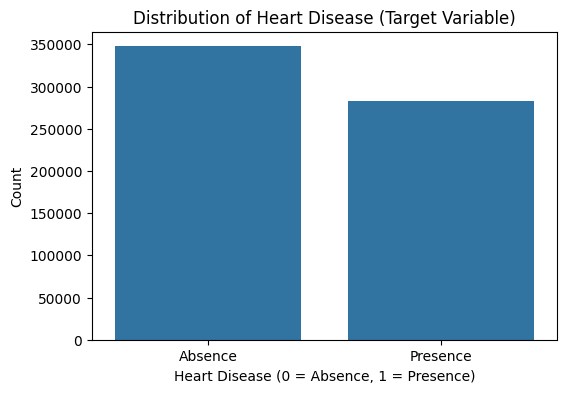

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Visualizing the distribution of the 'Heart Disease' target variable:")
plt.figure(figsize=(6, 4))
sns.countplot(x='Heart Disease', data=train_df)
plt.title('Distribution of Heart Disease (Target Variable)')
plt.xlabel('Heart Disease (0 = Absence, 1 = Presence)')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Absence', 'Presence'])
plt.show()

In [8]:
print("Checking for outliers using the IQR method:")

# Identify numerical columns (excluding the target variable 'Heart Disease')
numerical_cols = train_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'Heart Disease' in numerical_cols:
    numerical_cols.remove('Heart Disease')

outliers_summary = {}

for column in numerical_cols:
    Q1 = train_df[column].quantile(0.25)
    Q3 = train_df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Count outliers
    outliers = train_df[(train_df[column] < lower_bound) | (train_df[column] > upper_bound)]
    outliers_summary[column] = len(outliers)

# Display the summary of outliers
if any(outliers_summary.values()):
    print("Outliers detected in the following columns (count of outliers):")
    for col, count in outliers_summary.items():
        if count > 0:
            print(f"- {col}: {count}")
else:
    print("No significant outliers detected in numerical columns using the IQR method.")

Checking for outliers using the IQR method:
Outliers detected in the following columns (count of outliers):
- Age: 1048
- Chest pain type: 28602
- BP: 9011
- Cholesterol: 2194
- FBS over 120: 50392
- Max HR: 14246
- ST depression: 9971
- Number of vessels fluro: 22857


In [10]:
from sklearn.model_selection import train_test_split

print("Splitting data into features (X) and target (y) and then into training and testing sets...")

# Separate features (X) and target (y)
X = train_df.drop('Heart Disease', axis=1)
y = train_df['Heart Disease']

# Split the data into training and testing sets (e.g., 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Data split complete. Here are the shapes of the resulting datasets:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Splitting data into features (X) and target (y) and then into training and testing sets...
Data split complete. Here are the shapes of the resulting datasets:
X_train shape: (504000, 13)
X_test shape: (126000, 13)
y_train shape: (504000,)
y_test shape: (126000,)


In [12]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

print("Initializing and training the XGBoost Classifier...")

# Initialize the XGBoost classifier (removed deprecated 'use_label_encoder')
xgb_model = XGBClassifier(eval_metric='logloss', random_state=42)

# Train the model
xgb_model.fit(X_train, y_train)

print("XGBoost model training complete.")

# Make predictions on the test set
y_pred = xgb_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

Initializing and training the XGBoost Classifier...
XGBoost model training complete.
Model Accuracy: 0.8895


In [15]:
from sklearn.metrics import classification_report

print("Classification Report for Test Data:")
print(classification_report(y_test, y_pred))

Classification Report for Test Data:
              precision    recall  f1-score   support

           0       0.89      0.91      0.90     69509
           1       0.88      0.87      0.88     56491

    accuracy                           0.89    126000
   macro avg       0.89      0.89      0.89    126000
weighted avg       0.89      0.89      0.89    126000



In [16]:
print("Classification Report for Training Data:")
y_train_pred = xgb_model.predict(X_train)
print(classification_report(y_train, y_train_pred))

Classification Report for Training Data:
              precision    recall  f1-score   support

           0       0.90      0.91      0.90    278037
           1       0.89      0.87      0.88    225963

    accuracy                           0.89    504000
   macro avg       0.89      0.89      0.89    504000
weighted avg       0.89      0.89      0.89    504000



In [13]:
from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.91      0.90     69509
           1       0.88      0.87      0.88     56491

    accuracy                           0.89    126000
   macro avg       0.89      0.89      0.89    126000
weighted avg       0.89      0.89      0.89    126000



In [14]:
print("Classification Report for Training Data:")
y_train_pred = xgb_model.predict(X_train)
print(classification_report(y_train, y_train_pred))

Classification Report for Training Data:
              precision    recall  f1-score   support

           0       0.90      0.91      0.90    278037
           1       0.89      0.87      0.88    225963

    accuracy                           0.89    504000
   macro avg       0.89      0.89      0.89    504000
weighted avg       0.89      0.89      0.89    504000



In [17]:
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report

print("Initializing and training the LightGBM Classifier...")

# Initialize the LGBM classifier
lgbm_model = LGBMClassifier(random_state=42)

# Train the model
lgbm_model.fit(X_train, y_train)

print("LightGBM model training complete.")

# Make predictions on the test set
y_pred_lgbm = lgbm_model.predict(X_test)

# Evaluate the model on test data
print("\nClassification Report for Test Data (LightGBM):")
print(classification_report(y_test, y_pred_lgbm))

# Make predictions on the training set
y_train_pred_lgbm = lgbm_model.predict(X_train)

# Evaluate the model on training data
print("\nClassification Report for Training Data (LightGBM):")
print(classification_report(y_train, y_train_pred_lgbm))

Initializing and training the LightGBM Classifier...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 225963, number of negative: 278037
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.119531 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 372
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.448339 -> initscore=-0.207383
[LightGBM] [Info] Start training from score -0.207383
LightGBM model training complete.

Classification Report for Test Data (LightGBM):
              precision    recall  f1-score   support

           0       0.89      0.91      0.90     69509
           1       0.88      0.87      0.88     56491

    accuracy                           0.89    126000
   macro avg       0.89      0.89      0.89    126000
weighted avg    

In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

print("Initializing and training the Random Forest Classifier...")

# Initialize the Random Forest classifier
rf_model = RandomForestClassifier(random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest model training complete.")

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model on test data
print("\nClassification Report for Test Data (Random Forest):")
print(classification_report(y_test, y_pred_rf))

# Make predictions on the training set
y_train_pred_rf = rf_model.predict(X_train)

# Evaluate the model on training data
print("\nClassification Report for Training Data (Random Forest):")
print(classification_report(y_train, y_train_pred_rf))

Initializing and training the Random Forest Classifier...
Random Forest model training complete.

Classification Report for Test Data (Random Forest):
              precision    recall  f1-score   support

           0       0.89      0.90      0.89     69509
           1       0.87      0.86      0.87     56491

    accuracy                           0.88    126000
   macro avg       0.88      0.88      0.88    126000
weighted avg       0.88      0.88      0.88    126000


Classification Report for Training Data (Random Forest):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    278037
           1       1.00      1.00      1.00    225963

    accuracy                           1.00    504000
   macro avg       1.00      1.00      1.00    504000
weighted avg       1.00      1.00      1.00    504000



In [19]:
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score
import numpy as np

print("Tuning 'n_estimators' for LightGBM Classifier...")

# Define a range of n_estimators values to test
n_estimators_range = [50, 100, 200, 300, 400]
accuracies = []
best_accuracy = 0
best_n_estimators = 0

for n_est in n_estimators_range:
    print(f"Testing LightGBM with n_estimators = {n_est}...")
    lgbm_tuned_model = LGBMClassifier(n_estimators=n_est, random_state=42)
    lgbm_tuned_model.fit(X_train, y_train)
    y_pred_tuned = lgbm_tuned_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred_tuned)
    accuracies.append(acc)
    print(f"Accuracy for n_estimators = {n_est}: {acc:.4f}")

    if acc > best_accuracy:
        best_accuracy = acc
        best_n_estimators = n_est

print(f"\nBest n_estimators found: {best_n_estimators} with accuracy: {best_accuracy:.4f}")
print("This is a basic tuning approach. For more robust results, consider cross-validation or more advanced techniques like GridSearchCV or RandomizedSearchCV.")

Tuning 'n_estimators' for LightGBM Classifier...
Testing LightGBM with n_estimators = 50...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 225963, number of negative: 278037
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.191645 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 372
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.448339 -> initscore=-0.207383
[LightGBM] [Info] Start training from score -0.207383
Accuracy for n_estimators = 50: 0.8880
Testing LightGBM with n_estimators = 100...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 225963, number of negative: 278037
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.055264 s

In [20]:
from imblearn.over_sampling import SMOTE
from collections import Counter

print("Original class distribution in y_train:", Counter(y_train))

print("Applying SMOTE to the training data...")

smt = SMOTE(random_state=42)
X_train_smote, y_train_smote = smt.fit_resample(X_train, y_train)

print("SMOTE application complete.")
print("New class distribution in y_train_smote:", Counter(y_train_smote))
print(f"New X_train_smote shape: {X_train_smote.shape}")
print(f"New y_train_smote shape: {y_train_smote.shape}")

Original class distribution in y_train: Counter({0: 278037, 1: 225963})
Applying SMOTE to the training data...
SMOTE application complete.
New class distribution in y_train_smote: Counter({1: 278037, 0: 278037})
New X_train_smote shape: (556074, 13)
New y_train_smote shape: (556074,)


In [22]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score

print("Initializing and training the XGBoost Classifier on SMOTE-resampled data...")

# Initialize the XGBoost classifier
# We will use the 'best_n_estimators' if determined or a default otherwise
# For simplicity, let's use the default or a reasonable number if not explicitly tuned for XGBoost yet.
# If a best n_estimators was found for LightGBM, it might be a good starting point for XGBoost too, but for a fresh run, default is fine.
# Let's re-initialize with a default or previously known good setting for XGBoost
xgb_model_smote = XGBClassifier(eval_metric='logloss', random_state=42)

# Train the model on SMOTE-resampled data
xgb_model_smote.fit(X_train_smote, y_train_smote)

print("XGBoost model training complete on SMOTE data.")

# Make predictions on the original test set
y_pred_xgb_smote = xgb_model_smote.predict(X_test)

# Evaluate the model on test data
accuracy_xgb_smote = accuracy_score(y_test, y_pred_xgb_smote)
print(f"\nModel Accuracy on Test Data (XGBoost with SMOTE): {accuracy_xgb_smote:.4f}")
print("Classification Report for Test Data (XGBoost with SMOTE):")
print(classification_report(y_test, y_pred_xgb_smote))

# Make predictions on the SMOTE-resampled training set for consistency (optional, but good for understanding training performance on balanced data)
y_train_pred_xgb_smote = xgb_model_smote.predict(X_train_smote)

# Evaluate the model on SMOTE-resampled training data
print("\nClassification Report for Training Data (XGBoost with SMOTE):")
print(classification_report(y_train_smote, y_train_pred_xgb_smote))

Initializing and training the XGBoost Classifier on SMOTE-resampled data...
XGBoost model training complete on SMOTE data.

Model Accuracy on Test Data (XGBoost with SMOTE): 0.8878
Classification Report for Test Data (XGBoost with SMOTE):
              precision    recall  f1-score   support

           0       0.90      0.90      0.90     69509
           1       0.87      0.88      0.88     56491

    accuracy                           0.89    126000
   macro avg       0.89      0.89      0.89    126000
weighted avg       0.89      0.89      0.89    126000


Classification Report for Training Data (XGBoost with SMOTE):
              precision    recall  f1-score   support

           0       0.89      0.90      0.89    278037
           1       0.90      0.89      0.89    278037

    accuracy                           0.89    556074
   macro avg       0.89      0.89      0.89    556074
weighted avg       0.89      0.89      0.89    556074

